In [65]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v261\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

In [66]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [67]:
modeApi = lumapi.MODE(hide = False)
#units

um = 1e-6
nm = 1e-9
GHz = 1e9

## Defining the guide and solver dimensions and properties ##

In [68]:
x_span = 500*nm
y_span = 220*nm

## base materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'
new_material = 'Si (Silicon) - Modified Palik'

dn_dT = 1.87e-4

modeApi.setmaterial(modeApi.addmaterial('Index perturbation'), 'name', new_material)
modeApi.setmaterial(new_material, 'Base Material', material)
modeApi.setmaterial(new_material, 'dn/dT', dn_dT)

# span and mesh

x_span_FDE = 5*x_span
y_span_FDE = 5*y_span

mesh = 100
mesh_multiplier = 3

wavelength = 1550*nm
start_wavelength = 1500*nm
stop_wavelength = 1600*nm

## Building the device ##

In [69]:
modeApi.addrect()
modeApi.set('name', 'waveguide')
modeApi.set('x', 0)
modeApi.set('x span', x_span)
modeApi.set('y', 0)
modeApi.set('y span', y_span)
modeApi.set('material', new_material)

modeApi.addfde()
modeApi.set('x', 0)
modeApi.set('x span', x_span_FDE)
modeApi.set('y', 0)
modeApi.set('y span', y_span_FDE)
modeApi.set('background material', sub_material)
modeApi.set('mesh cells x', mesh)
modeApi.set('mesh cells y', mesh)
modeApi.set('wavelength', wavelength)

modeApi.addmesh()
modeApi.set('x', 0)
modeApi.set('x span', x_span)
modeApi.set('y', 0)
modeApi.set('y span', y_span)
modeApi.set('set mesh multiplier', 1)
modeApi.set('x mesh multiplier', mesh_multiplier)
modeApi.set('y mesh multiplier', mesh_multiplier)

modeApi.save('FDE MZI waveguide')

## Obtaining the results ##

In [70]:
number_of_modes = int(modeApi.findmodes())

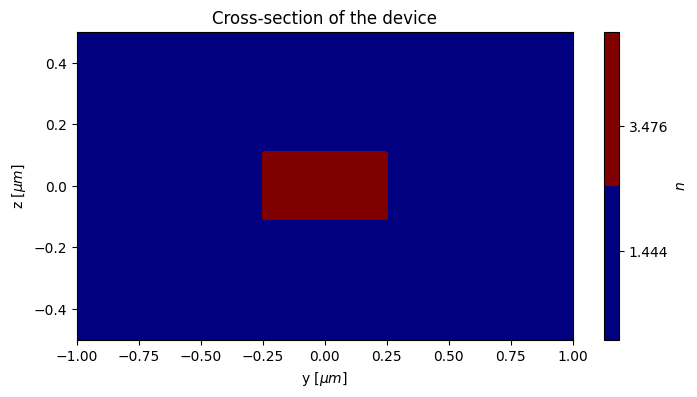

In [71]:
eField_x = np.squeeze(modeApi.getresult('FDE::data::mode1', 'Ex'))
eField_y = np.squeeze(modeApi.getresult('FDE::data::mode1', 'Ey'))
eField_z = np.squeeze(modeApi.getresult('FDE::data::mode1', 'Ez'))
eField = np.sqrt(eField_x**2 + eField_y**2 + eField_z**2)
x_eField = modeApi.getresult('FDE::data::mode1', 'x')/um
y_eField = modeApi.getresult('FDE::data::mode1', 'y')/um
n_eff = (modeApi.getresult('FDE::data::mode1', 'neff').real)[0,0]
n_group = (modeApi.getresult('FDE::data::mode1', 'ng').real)[0,0]

rfIndex = np.squeeze(modeApi.getresult('FDE::data::material', 'index_x'))
v = np.linspace(np.min(rfIndex), np.max(rfIndex), 2)

X, Y = np.meshgrid(x_eField, y_eField)

im = plt.contourf(X, Y, np.rot90(rfIndex), 0, cmap = plt.get_cmap('jet'), vmin = v[0], vmax = v[-1], origin = 'lower')
colorbar = plt.colorbar(im, label = r'$n$')
colorbar.set_ticks(v)
plt.xlabel(r'y [$\mu m$]')
plt.ylabel(r'z [$\mu m$]')
plt.title('Cross-section of the device')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)
plt.show()

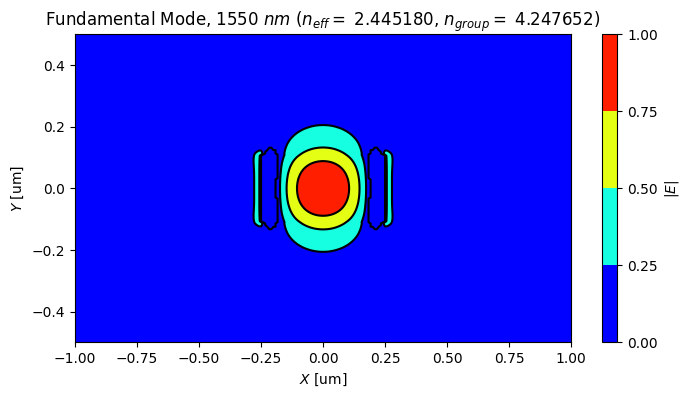

C:\Users\LucasGabriel\AppData\Local\Temp\ipykernel_11292\8575138.py:23: RuntimeWarning: divide by zero encountered in log10
  eField_dB = 10*np.log10((eField.real)**2)


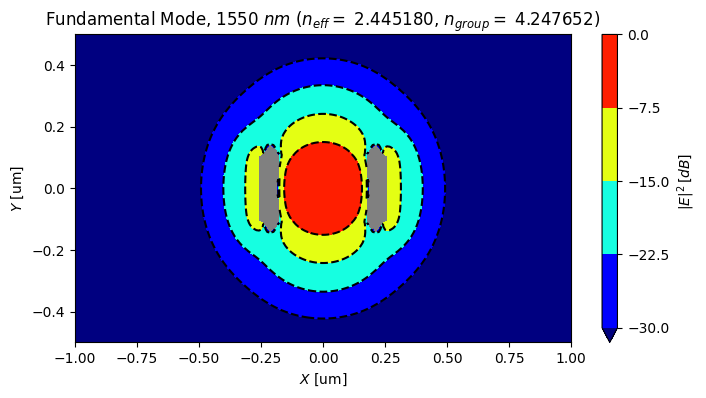

In [93]:
v = np.linspace(0, 1, 5)

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
plt.contourf(X, Y, np.rot90(rfIndex.real), 0, colors = 'gray', origin = 'lower')
plt.contour(X, Y, np.rot90(eField.real), v, colors = 'k', vmin = 0, vmax = 1)
im = plt.contourf(X, Y, np.rot90(eField.real), v, cmap = plt.cm.jet, vmin = 0, vmax = 1)
#im = plt.contourf(X, Y, np.rot90(eField.real), cmap = plt.cm.jet)

colorbar = plt.colorbar(im)
colorbar.set_ticks(v)
colorbar.set_label(r'$|E|$')

plt.xlabel(r'$X$ ' + r'$\mathrm{[um]}$')
plt.ylabel(r'$Y$ ' + r'$ \mathrm{[um]}$')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)

plt.title(r'Fundamental Mode, %d $nm$ ($n_{eff} =$ %.6f, $n_{group} =$ %.6f)' %(wavelength/nm, n_eff, n_group))
plt.show()


eField_dB = 10*np.log10((eField.real)**2)

v = np.linspace(-30, 0, 5)
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)
plt.contourf(X, Y, np.rot90(rfIndex.real), 0, colors = 'gray', origin = 'lower')
plt.contour(X, Y, np.rot90(eField_dB), v, colors = 'k', vmin = -30, vmax = 0, extend = 'min')
im1 = plt.contourf(X, Y, np.rot90(eField_dB), v, cmap = plt.cm.jet, vmin = -30, vmax = 0, extend = 'min')
#im = plt.contourf(X, Y, np.rot90(eField.real), cmap = plt.cm.jet)

colorbar = plt.colorbar(im1)
colorbar.set_ticks(v)
colorbar.set_label(r'$|E|^2\,[dB]$')

plt.xlabel(r'$X$ ' + r'$\mathrm{[um]}$')
plt.ylabel(r'$Y$ ' + r'$ \mathrm{[um]}$')
plt.xlim(-1, 1)
plt.ylim(-0.5, 0.5)

plt.title(r'Fundamental Mode, %d $nm$ ($n_{eff} =$ %.6f, $n_{group} =$ %.6f)' %(wavelength/nm, n_eff, n_group))
plt.show()

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(19, 8))

im1 = ax[0].contourf(X, Y, np.rot90(eField), 0, cmap = plt.get_cmap('jet'), vmin = 0, vmax = np.max(eField))
ax[0].set_title(r'Component $E_x$ of mode TE3')
ax[0].set_xlabel(r'x [$\mu m$]')
ax[0].set_ylabel(r'y [$\mu m$]')

im2 =ax[1].contourf(X, Y, np.rot90(eField), 0, cmap = plt.get_cmap('jet'), vmin = 0, vmax = np.max(eField))
ax[1].set_title(r'Component $E_x$ of mode TM0')
ax[1].set_xlabel(r'x [$\mu m$]')
ax[1].set_ylabel(r'y [$\mu m$]')

fig.colorbar(im1, ax=ax[0], fraction = 0.021, pad =0.02, label = r'$|E_x|$')
fig.colorbar(im2, ax=ax[1], fraction = 0.021, pad =0.02, label = r'$|E_x|$')

plt.show()

In [ ]:
modeApi.switchtolayout()

#obtaining the effective index and the group index for different temperatures

dT = 10 #K
T0 = 300 #K
Tf = 400 #K

n_temperatures = int((Tf - T0)/dT) + 1
T = np.linspace(T0, Tf, n_temperatures)

index_matrix = np.zeros((n_temperatures, 2))

In [ ]:
for k in range(0, n_temperatures, 1):
    modeApi.switchtolayout()
    modeApi.setnamed('FDE', 'simulation temperature', T[k])
    modeApi.findmodes()

    n_eff = (modeApi.getresult('FDE::data::mode1', 'neff').real)[0,0]
    n_group = (modeApi.getresult('FDE::data::mode1', 'ng').real)[0,0]

    index_matrix[k, 0] = n_eff
    index_matrix[k, 1] = n_group

np.savetxt('index.txt', index_matrix)

In [63]:
modeApi.close()